## The simplest way to upload files to the Hub is by leveraging the push_to_hub API.

Before going further, you’ll need to generate an authentication token so that the huggingface_hub API knows who you are and what namespaces you have write access to. Make sure you are in an environment where you have transformers installed.If you are in a notebook, you can use the following function to login:

In [3]:
from huggingface_hub import notebook_login

notebook_login()
# here past your hf token.

In [ ]:
## In a terminal, you can run:
## huggingface-cli login

In both cases, you should be prompted for your username and password, which are the same ones you use to log in to the Hub.

You now have your authentication token stored in your cache folder. Let’s create some repositories!

If you have played around with the Trainer API to train a model, the easiest way to upload it to the Hub is to set push_to_hub=True when you define your TrainingArguments:

In [ ]:
from transformers import TrainingArguments

traning_args = TraningArguments(
    "bert-finetuned-mrpc" ,save_strategy = "epoch" , push_to_hug = True
)

When you call trainer.train(), the Trainer will then upload your model to the Hub each time it is saved (here every epoch) in a repository in your namespace. That repository will be named like the output directory you picked (here bert-finetuned-mrpc) but you can choose a different name with hub_model_id = "a_different_name".

To upload your model to an organization you are a member of, just pass it with hub_model_id = "my_organization/my_repo_name".

Once your training is finished, you should do a final trainer.push_to_hub() to upload the last version of your model. It will also generate a model card with all the relevant metadata, reporting the hyperparameters used and the evaluation results! Here is an example of the content you might find in a such a model card:

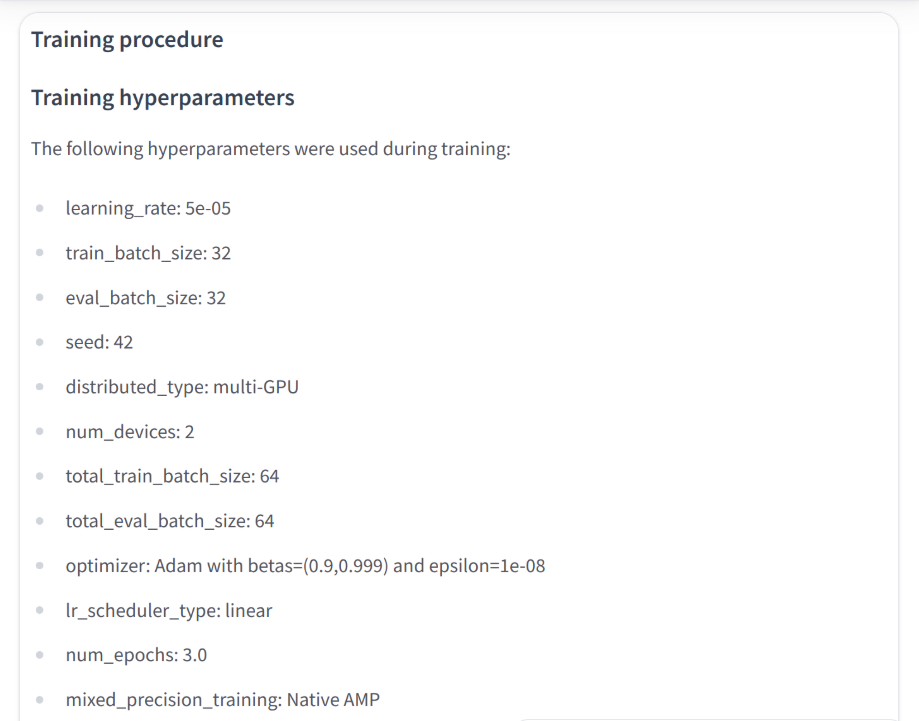


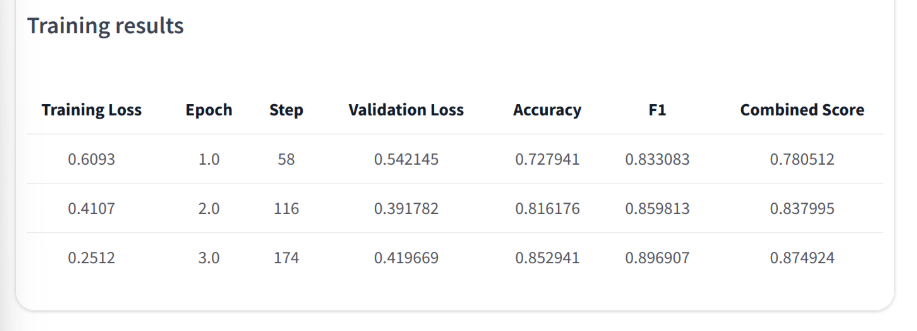

## To get an idea of how it works, let’s first initialize a model and a tokenizer:



In [12]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

checkpoint = "camembert-base"

model = AutoModelForMaskedLM.from_pretrained(checkpoint)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

Some weights of the model checkpoint at camembert-base were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


You’re free to do whatever you want with these — add tokens to the tokenizer, train the model, fine-tune it. Once you’re happy with the resulting model, weights, and tokenizer, you can leverage the push_to_hub() method directly available on the model object:

In [ ]:
model.push_to_hub("dummy-model")

This will create the new repository dummy-model in your profile, and populate it with your model files. Do the same with the tokenizer, so that all the files are now available in this repository:

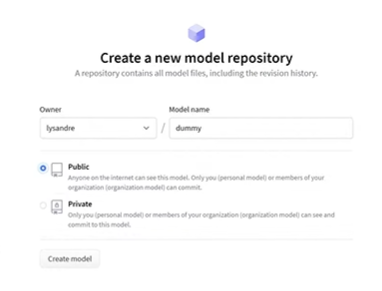


In [ ]:
tokenizer.push_to_hub("dummy-model")

If you belong to an organization, simply specify the organization argument to upload to that organization’s (like Sakhawats ) namespace:

In [ ]:
tokenizer.push_to_hub("dummy-model",organization = "sakhawats")

If you wish to use a specific Hugging Face token, you’re free to specify it to the push_to_hub() method as well:

In [ ]:
tokenizer.push_to_hub("dummy-model",organization="sakhawats",use_auth_token = "<enther your token>")

Now head to the Model Hub to find your newly uploaded model: https://huggingface.co/user-or-organization/dummy-model.

Click on the “Files and versions” tab, and you should see the files visible in the following screenshot:

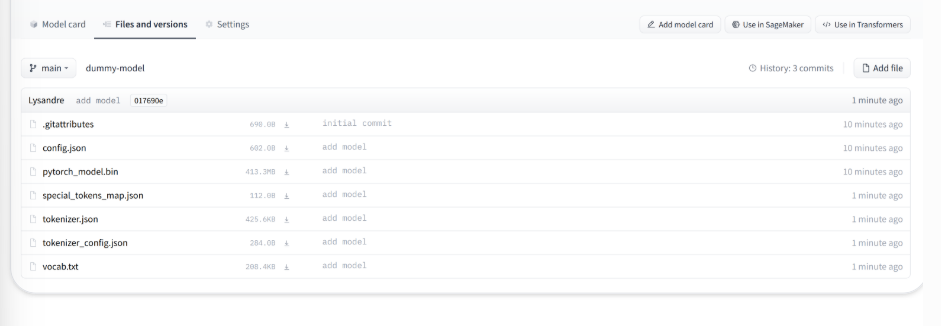

As you’ve seen, the push_to_hub() method accepts several arguments, making it possible to upload to a specific repository or organization namespace, or to use a different API token. We recommend you take a look at the method specification available directly in the Transformers documentation ( https://huggingface.co/docs/transformers/model_sharing )  to get an idea of what is possible.

In [ ]:
`